In [30]:
# DATA COLLECTION

# Import Libraries
import pandas as pd
import numpy as np
import datetime as dt
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pointbiserialr

# Suppress warnings
warnings.filterwarnings("ignore")

# Load Dataset
df = pd.read_csv('ifood_df.csv')

# EXPLORING DATA

# Dataset Overview
print("Dataset First Look:")
print(df.head())

# Dataset Information
# The following cell displays general information about the dataset, including the number of entries, column names, data types, and memory usage.
print("\nDataset Info:")
df.info()

# Display Dataset Description
print("\nDataset Description:")
print(df.describe())

# Check Unique Values for each variable
unique_values = df.nunique()
print("\nUnique Values for each variable:")
print(unique_values)

# Check for duplicates
duplicates_count = df.duplicated().sum()
print(f"\nNumber of duplicates: {duplicates_count}")

# Missing Values/Null Values Count
missing_values = df.isnull().sum()
print("\nMissing Values Count:")
print(missing_values)

# Dropping irrelevant columns
df.drop(columns=['Z_CostContact', 'Z_Revenue'], inplace=True)

# Display the cleaned dataset
print("\nCleaned Dataset:")
print(df.head())


Dataset First Look:
   Income  Kidhome  Teenhome  Recency  MntWines  MntFruits  MntMeatProducts  \
0   58138        0         0       58       635         88              546   
1   46344        1         1       38        11          1                6   
2   71613        0         0       26       426         49              127   
3   26646        1         0       26        11          4               20   
4   58293        1         0       94       173         43              118   

   MntFishProducts  MntSweetProducts  MntGoldProds  ...  marital_Together  \
0              172                88            88  ...                 0   
1                2                 1             6  ...                 0   
2              111                21            42  ...                 1   
3               10                 3             5  ...                 1   
4               46                27            15  ...                 0   

   marital_Widow  education_2n Cycle  educ

# Project : Customer Segmentation

**Goals:**
- Add reproducible EDA and preprocessing steps
- Run clustering (KMeans) with evaluation (elbow & silhouette)
- Profile clusters and create visual summaries
- Provide instructions and requirements in `README.md`

**Notebook workflow:**
1. Load data and initial checks
2. Data cleaning and preprocessing
3. Exploratory data analysis (visuals, correlations)
4. Dimensionality reduction (PCA) + clustering (KMeans)
5. Cluster profiling and export

In [31]:
# Additional imports for enhancements
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

Shape: (2205, 37)

Missing values per column:
Income                  0
Kidhome                 0
Teenhome                0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Response                0
Age                     0
Customer_Days           0
marital_Divorced        0
marital_Married         0
marital_Single          0
marital_Together        0
marital_Widow           0
education_2n Cycle      0
education_Basic         0
education_Graduation    0
education_Master        0
education_PhD           0
MntTotal                0
MntRegularProds         0
AcceptedCmpOverall

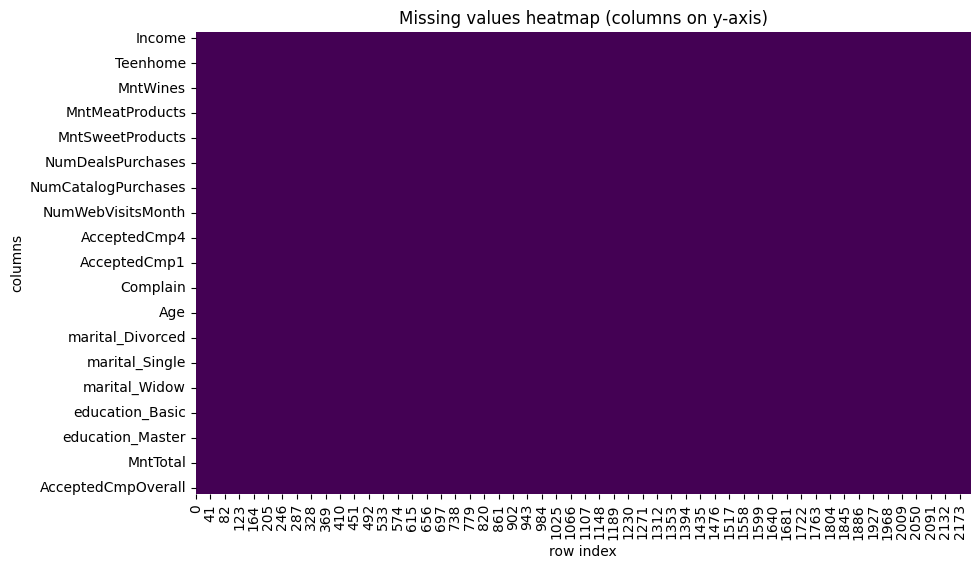


Numeric columns: ['Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Response', 'Age', 'Customer_Days', 'marital_Divorced', 'marital_Married', 'marital_Single', 'marital_Together', 'marital_Widow', 'education_2n Cycle', 'education_Basic', 'education_Graduation', 'education_Master', 'education_PhD', 'MntTotal', 'MntRegularProds', 'AcceptedCmpOverall']


,count,mean,std,min,25%,50%,75%,max
Income,2205.0,51622.094785,20713.063826,1730.0,35196.0,51287.0,68281.0,113734.0
Kidhome,2205.0,0.442177,0.537132,0.0,0.0,0.0,1.0,2.0
Teenhome,2205.0,0.506576,0.544380,0.0,0.0,0.0,1.0,2.0
Recency,2205.0,49.009070,28.932111,0.0,24.0,49.0,74.0,99.0
MntWines,2205.0,306.164626,337.493839,0.0,24.0,178.0,507.0,1493.0
MntFruits,2205.0,26.403175,39.784484,0.0,2.0,8.0,33.0,199.0
MntMeatProducts,2205.0,165.312018,217.784507,0.0,16.0,68.0,232.0,1725.0
MntFishProducts,2205.0,37.756463,54.824635,0.0,3.0,12.0,50.0,259.0
MntSweetProducts,2205.0,27.128345,41.130468,0.0,1.0,8.0,34.0,262.0
MntGoldProds,2205.0,44.057143,51.736211,0.0,9.0,25.0,56.0,321.0


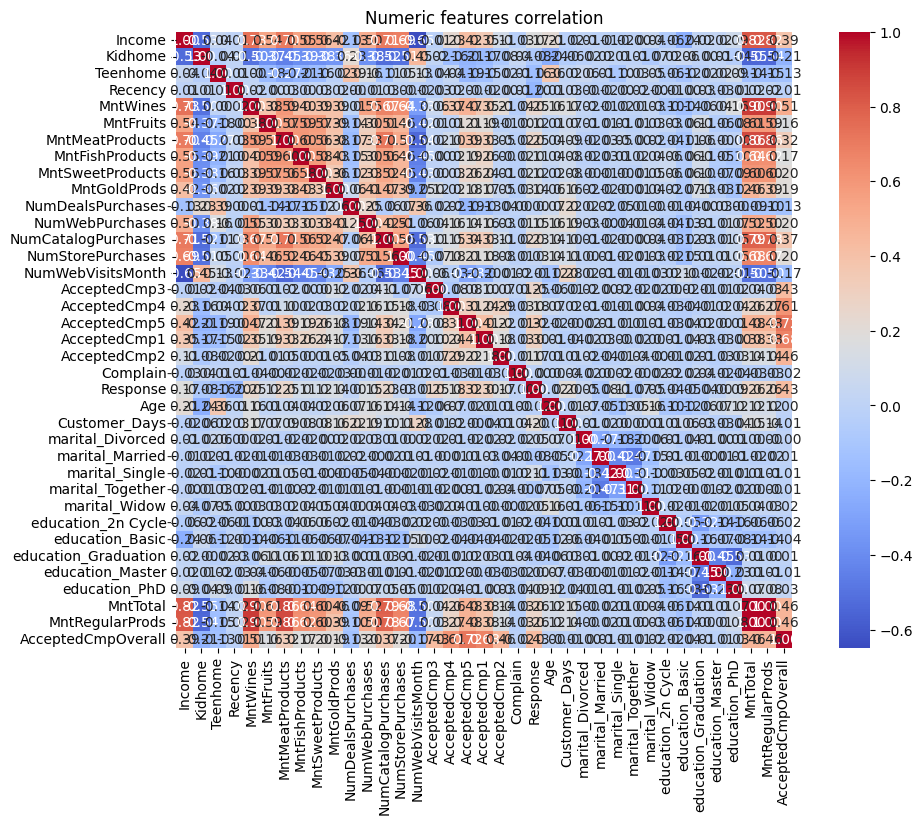

In [32]:
# Quick EDA: shape, missing values, and basic distributions
from IPython.display import display

if 'df' not in globals():
    raise NameError("DataFrame 'df' is not defined. Run the data-loading cell first.")

print('Shape:', df.shape)
print('\nMissing values per column:')
print(df.isnull().sum())

# Visualize missingness (simple heatmap)
plt.figure(figsize=(10,6))
# convert boolean to int for plotting and transpose so columns are on the y-axis (more readable)
sns.heatmap(df.isnull().astype(int).T, cbar=False, cmap='viridis')
plt.title('Missing values heatmap (columns on y-axis)')
plt.xlabel('row index')
plt.ylabel('columns')
plt.show()

# Show numeric column summary
if 'numeric_cols' not in globals():
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print('\nNumeric columns:', numeric_cols)
display(df[numeric_cols].describe().T)

# Correlation matrix (numeric only)
if len(numeric_cols) > 1:
    corr = df[numeric_cols].corr()
    plt.figure(figsize=(12,8))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
    plt.title('Numeric features correlation')
    plt.show()
else:
    print('Not enough numeric columns to compute correlation.')

Explained variance ratio by first 2 components: [0.2422817 0.0694103]


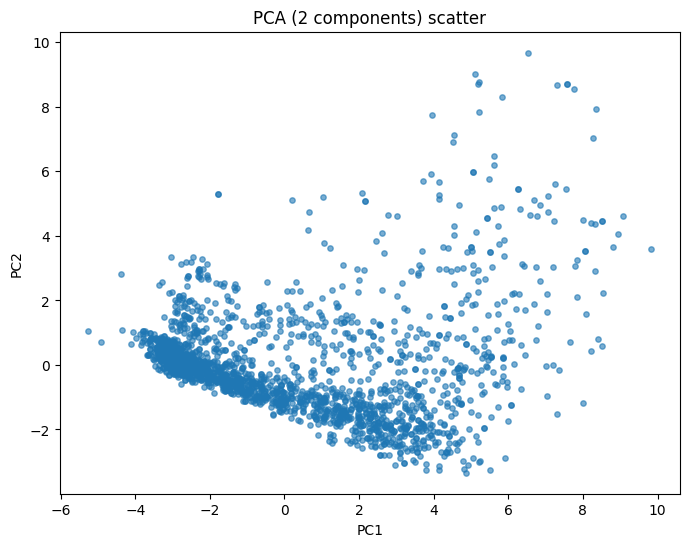

In [33]:
# Preprocessing: keep numeric features, impute median, scale
X = df.select_dtypes(include=[np.number]).copy()
# If there are no numeric columns, stop here
if X.shape[1] == 0:
    raise ValueError('No numeric columns found for clustering. Consider encoding features first.')

# Impute missing numeric values with median
X = X.fillna(X.median())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Use PCA(2) for visualization but keep full data for clustering
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print('Explained variance ratio by first 2 components:', pca.explained_variance_ratio_)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], s=15, alpha=0.6)
plt.xlabel('PC1'), plt.ylabel('PC2'), plt.title('PCA (2 components) scatter')
plt.show()

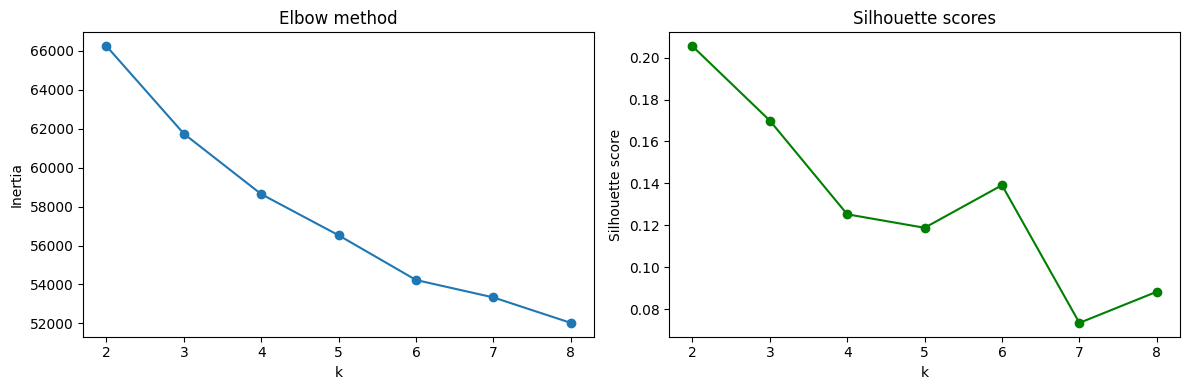

Best k by silhouette score: 2


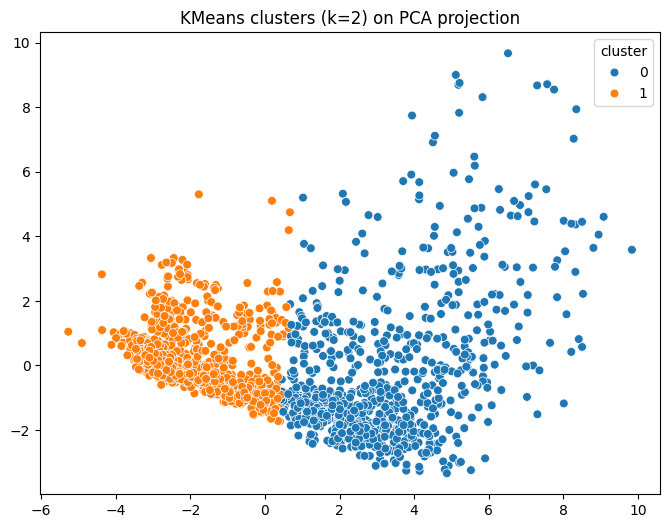

In [34]:
# Find optimal K using elbow method and silhouette score
inertia = []
sil_scores = []
K_RANGE = range(2,9)
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(list(K_RANGE), inertia, '-o')
plt.xlabel('k'), plt.ylabel('Inertia'), plt.title('Elbow method')

plt.subplot(1,2,2)
plt.plot(list(K_RANGE), sil_scores, '-o', color='green')
plt.xlabel('k'), plt.ylabel('Silhouette score'), plt.title('Silhouette scores')
plt.tight_layout()
plt.show()

# Choose best k by highest silhouette score
best_k = K_RANGE[np.argmax(sil_scores)]
print('Best k by silhouette score:', best_k)

# Fit final KMeans
kmeans = KMeans(n_clusters=int(best_k), random_state=42, n_init=20)
clusters = kmeans.fit_predict(X_scaled)
df['cluster'] = clusters

# Visualize clusters on PCA components
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=clusters, palette='tab10', s=40)
plt.title(f'KMeans clusters (k={best_k}) on PCA projection')
plt.legend(title='cluster')
plt.show()

In [35]:
# Cluster profiling: group means and sizes
profile = df.copy()
profile_stats = profile.groupby('cluster').agg(['count','mean']).T
# A compact cluster distribution
cluster_sizes = df['cluster'].value_counts().sort_index()
print('Cluster sizes:')
print(cluster_sizes)

# Show numeric feature means per cluster
numeric_means = df.groupby('cluster')[numeric_cols].mean()
display(numeric_means)

# Save cluster assignments
df.to_csv('ifood_df_with_clusters.csv', index=False)
print('Saved ifood_df_with_clusters.csv')

Cluster sizes:
cluster
0     872
1    1333
Name: count, dtype: int64


,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
cluster,,,,,,,,,,,,,,,,,,,,,
0,71482.579128,0.065367,0.426606,49.505734,621.900229,55.949541,359.909404,79.697248,57.597477,75.482798,...,0.253440,0.043578,0.079128,0.001147,0.529817,0.151376,0.238532,1175.053899,1099.571101,0.598624
1,38630.090023,0.688672,0.558890,48.684171,99.621905,7.075019,38.013503,10.320330,7.196549,23.499625,...,0.260315,0.028507,0.096774,0.039760,0.488372,0.174044,0.201050,162.227307,138.727682,0.103526


Saved ifood_df_with_clusters.csv


Categorical columns: []
Low-cardinality: []
High-cardinality: []
Combined feature shape (numeric + encoded): (2205, 37)


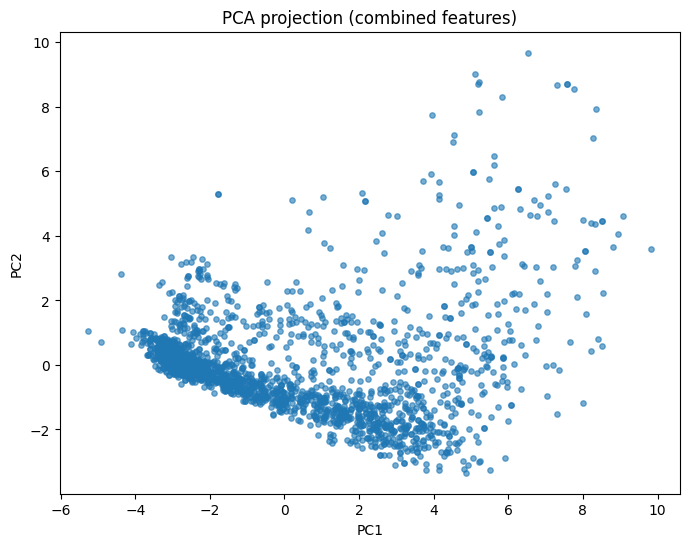

In [36]:
# --- Categorical handling, retrain clustering on combined features ---
# Identify categorical columns
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print('Categorical columns:', cat_cols)

# Start from numeric features already in X (from earlier cell)
X_full = X.copy()

# Simple strategy: one-hot encode low-cardinality categorical cols (<=10), frequency-encode high-cardinality
low_card = [c for c in cat_cols if df[c].nunique() <= 10]
high_card = [c for c in cat_cols if df[c].nunique() > 10]
print('Low-cardinality:', low_card)
print('High-cardinality:', high_card)

from sklearn.preprocessing import OneHotEncoder
if low_card:
    ohe = OneHotEncoder(drop='first', sparse=False, handle_unknown='ignore')
    ohe_arr = ohe.fit_transform(df[low_card].fillna('NA'))
    ohe_cols = list(ohe.get_feature_names_out(low_card))
    ohe_df = pd.DataFrame(ohe_arr, columns=ohe_cols, index=df.index)
    X_full = pd.concat([X_full, ohe_df], axis=1)

# Frequency encoding for high-cardinality columns
for c in high_card:
    freq = df[c].fillna('NA').map(df[c].value_counts(normalize=True))
    X_full[c + '_freq'] = freq.fillna(0)

print('Combined feature shape (numeric + encoded):', X_full.shape)

# Impute any remaining missing values and scale
X_full = X_full.fillna(X_full.median())
scaler_full = StandardScaler()
X_full_scaled = scaler_full.fit_transform(X_full)

# PCA projection for visualization
pca_full = PCA(n_components=2, random_state=42)
X_full_pca = pca_full.fit_transform(X_full_scaled)
plt.figure(figsize=(8,6))
plt.scatter(X_full_pca[:,0], X_full_pca[:,1], s=15, alpha=0.6)
plt.xlabel('PC1'), plt.ylabel('PC2'), plt.title('PCA projection (combined features)')
plt.show()

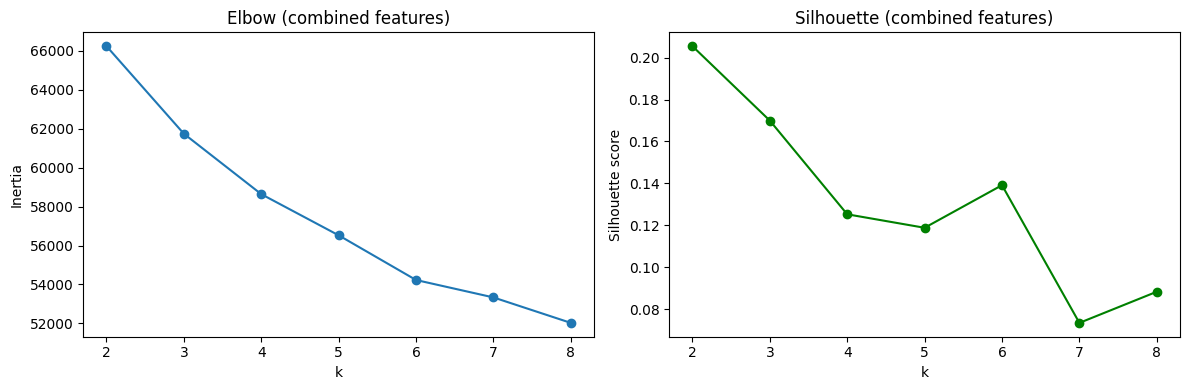

Best k (combined features) by silhouette: 2


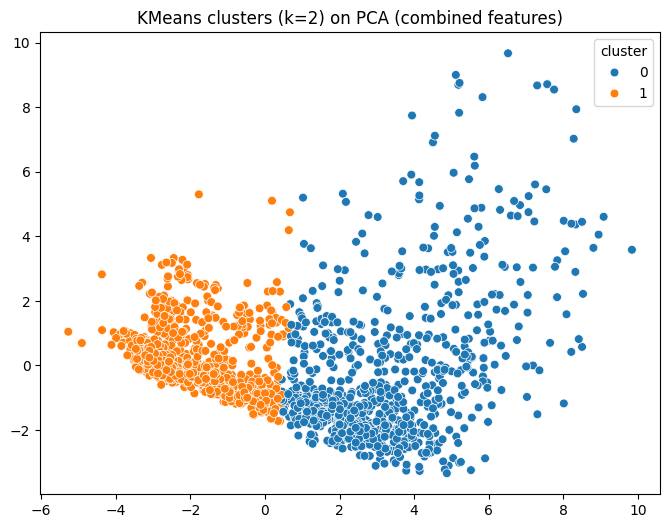

In [37]:
# Re-evaluate optimal K on combined features
inertia_full = []
sil_scores_full = []
K_RANGE = range(2,9)
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_full_scaled)
    inertia_full.append(km.inertia_)
    sil_scores_full.append(silhouette_score(X_full_scaled, km.labels_))

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(list(K_RANGE), inertia_full, '-o')
plt.xlabel('k'), plt.ylabel('Inertia'), plt.title('Elbow (combined features)')

plt.subplot(1,2,2)
plt.plot(list(K_RANGE), sil_scores_full, '-o', color='green')
plt.xlabel('k'), plt.ylabel('Silhouette score'), plt.title('Silhouette (combined features)')
plt.tight_layout()
plt.show()

best_k_full = K_RANGE[np.argmax(sil_scores_full)]
print('Best k (combined features) by silhouette:', best_k_full)

# Fit final model and assign clusters
kmeans_full = KMeans(n_clusters=int(best_k_full), random_state=42, n_init=20)
clusters_full = kmeans_full.fit_predict(X_full_scaled)
df['cluster_full'] = clusters_full

# Visualize
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_full_pca[:,0], y=X_full_pca[:,1], hue=clusters_full, palette='tab10', s=40)
plt.title(f'KMeans clusters (k={best_k_full}) on PCA (combined features)')
plt.legend(title='cluster')
plt.show()

In [38]:
# Save artifacts (scaler, PCA, KMeans) using joblib
import joblib
joblib.dump(scaler_full, 'scaler_full.joblib')
joblib.dump(pca_full, 'pca_full.joblib')
joblib.dump(kmeans_full, 'kmeans_full.joblib')
print('Saved scaler_full.joblib, pca_full.joblib, kmeans_full.joblib')

# Quick inference example on 3 random rows
sample = df.sample(3, random_state=42)
sample_features = X_full.loc[sample.index]
sample_scaled = scaler_full.transform(sample_features)
preds = kmeans_full.predict(sample_scaled)
print('Sample indices and predicted clusters (cluster_full):')
print(list(zip(sample.index.tolist(), preds.tolist())))

# Save updated dataframe with new cluster assignment
df.to_csv('ifood_df_with_clusters_full.csv', index=False)
print('Saved ifood_df_with_clusters_full.csv')

Saved scaler_full.joblib, pca_full.joblib, kmeans_full.joblib
Sample indices and predicted clusters (cluster_full):
[(1966, 0), (1091, 0), (1468, 1)]
Saved ifood_df_with_clusters_full.csv


## Summary & Next Steps
- The notebook now performs basic preprocessing, PCA visualization, KMeans clustering with silhouette-based selection of k, and cluster profiling.
- Next steps: incorporate categorical features (one-hot or target-encoding), try other clustering algorithms (DBSCAN, Agglomerative), and build dashboards for reporting.
- If you want, I can also add an automated model save (`joblib`) and a small section to interpret clusters using feature importances.
